In [ ]:
# Step 0

import pandas as pd

# 1. Load the data
df = pd.read_csv('my_data_analysis_all_10_11_07.csv')

# 2. Data Cleaning & Type Conversion
df['Logged_At_Timestamp'] = pd.to_datetime(df['Logged_At_Timestamp'])
df['Next_Stop'] = df['Next_Stop'].astype('Int64')

# NEW CONDITION: Drop rows where "Next_Stop" is NULL (NaN)
df = df.dropna(subset=['Next_Stop'])

# 3. Sort by timestamp
df = df.sort_values(by=['Logged_At_Timestamp'])

# 4. Create your final snapshot grouped dataframe
final_stop_snapshots = df.groupby(['Trip_ID', 'Current_Stop']).last().reset_index()

# 5. Save whichever file version you need
final_stop_snapshots.to_csv('final_bus_snapshots.csv', index=False, encoding='utf-8-sig')

In [ ]:
# Step 1
# Combine ALL csv files

import glob
import os
import pandas as pd

# 1. Define the directory path
folder_path = "/Users/chanhsuanhung/Downloads/Bus data"

# 2. Grab all CSV files in that specific folder
# This matches any file ending with .csv in your Bus data directory
file_pattern = os.path.join(folder_path, "*.csv")
all_files = glob.glob(file_pattern)

# 3. Read and combine all CSV files into a single DataFrame
# Using a list comprehension is the fastest way to do this
df_list = [pd.read_csv(file) for file in all_files]
combined_df = pd.concat(df_list, ignore_index=True)

# 4. (Optional) Save the combined data to a new CSV file
output_path = os.path.join(folder_path, "combined_bus_data.csv")
combined_df.to_csv(output_path, index=False)

print(f"Successfully combined {len(all_files)} files!")
print(f"Saved to: {output_path}")

In [1]:
# Step 2
import pandas as pd

# Load the datasets
df_bus = pd.read_csv("combined_bus_data.csv")
df_weather = pd.read_csv("weather.csv")

# 1. Convert time columns to datetime format
df_bus["Logged_At_Timestamp"] = pd.to_datetime(df_bus["Logged_At_Timestamp"])
df_weather["time"] = pd.to_datetime(df_weather["time"])

# 2. Create a new column in bus data that rounds down to the nearest hour
df_bus["weather_lookup_time"] = df_bus["Logged_At_Timestamp"].dt.floor("h")

# 3. Merge the datasets on the hourly keys
df_merged = pd.merge(
    df_bus, df_weather, left_on="weather_lookup_time", right_on="time", how="left"
)

# 4. Display the dataframes
print("--- Weather Dataframe Preview ---")
display(df_weather.head())

print("\n--- Merged Dataframe Preview ---")
display(df_merged.head())

--- Weather Dataframe Preview ---


,time,temperature_2m (°C),apparent_temperature (°C),relative_humidity_2m (%),rain (mm),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C)
0,2026-06-29 00:00:00,22.8,23.9,77,0.0,0.0,1013.2,13.6,23.1,25.2,28.1,19.4
1,2026-06-29 01:00:00,21.9,23.2,74,0.0,0.0,1013.7,8.8,17.7,24.4,27.9,19.4
2,2026-06-29 02:00:00,21.6,23.5,76,0.0,0.0,1013.3,4.4,12.2,24.4,27.9,19.4
3,2026-06-29 03:00:00,20.9,22.9,80,0.0,0.0,1013.1,4.0,10.7,23.6,27.7,19.4
4,2026-06-29 04:00:00,20.6,21.7,80,0.0,0.0,1013.6,9.5,18.7,23.0,27.5,19.4



--- Merged Dataframe Preview ---


,id,Logged_At_Timestamp,Line,Vehicle_ID,Trip_ID,Direction,Direction_ID,Current_Stop,Next_Stop,Delay_Min,...,apparent_temperature (°C),relative_humidity_2m (%),rain (mm),precipitation (mm),surface_pressure (hPa),wind_speed_10m (km/h),wind_speed_100m (km/h),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C)
0,1,2026-07-06 04:48:26,5,2550,060726_100164_2_5_10,Nienberge Hannaschweg,1,4722802,47231.0,0.0,...,14.7,90.0,0.0,0.0,1010.7,11.8,23.3,16.5,20.4,18.7
1,2,2026-07-06 04:49:26,5,2550,060726_100164_2_5_10,Nienberge Hannaschweg,1,4722802,47231.0,0.0,...,14.7,90.0,0.0,0.0,1010.7,11.8,23.3,16.5,20.4,18.7
2,3,2026-07-06 04:50:26,5,2550,060726_100164_2_5_10,Nienberge Hannaschweg,1,4722802,47231.0,0.0,...,14.7,90.0,0.0,0.0,1010.7,11.8,23.3,16.5,20.4,18.7
3,4,2026-07-06 04:51:26,5,2359,060726_100072_2_5_9,Hiltrup Bahnhof,2,46930,46931.0,0.0,...,14.7,90.0,0.0,0.0,1010.7,11.8,23.3,16.5,20.4,18.7
4,5,2026-07-06 04:51:26,5,2550,060726_100164_2_5_10,Nienberge Hannaschweg,1,4722802,47231.0,0.0,...,14.7,90.0,0.0,0.0,1010.7,11.8,23.3,16.5,20.4,18.7


In [2]:
# Step 3
import numpy as np
import pandas as pd

# 1. Extract base time features
df_merged["hour"] = df_merged["Logged_At_Timestamp"].dt.hour
df_merged["day_of_week"] = df_merged["Logged_At_Timestamp"].dt.dayofweek

# 2. Cyclical encoding for Hour (Transforms 23 and 0 so they are close together)
df_merged["hour_sin"] = np.sin(2 * np.pi * df_merged["hour"] / 24.0)
df_merged["hour_cos"] = np.cos(2 * np.pi * df_merged["hour"] / 24.0)

# 3. Create Traffic Interaction Flags
# Define peak rush hours (e.g., 7-9 AM and 4-6 PM) on weekdays
df_merged["is_rush_hour"] = (
    ((df_merged["hour"].between(7, 9)) | (df_merged["hour"].between(16, 18)))
    & (df_merged["day_of_week"] < 5)
).astype(int)

# Create an interaction feature: Rain * Rush Hour
df_merged["rain_during_rush"] = df_merged["rain (mm)"] * df_merged["is_rush_hour"]

print("--- Merged Dataframe with Advanced Features ---")
display(df_merged[["Logged_At_Timestamp", "hour_sin", "hour_cos", "is_rush_hour", "rain_during_rush"]].tail())

--- Merged Dataframe with Advanced Features ---


,Logged_At_Timestamp,hour_sin,hour_cos,is_rush_hour,rain_during_rush
524327,2026-07-03 21:40:23,-0.707107,0.707107,0,0.0
524328,2026-07-03 21:41:24,-0.707107,0.707107,0,0.0
524329,2026-07-03 21:42:23,-0.707107,0.707107,0,0.0
524330,2026-07-03 21:43:23,-0.707107,0.707107,0,0.0
524331,2026-07-03 21:44:23,-0.707107,0.707107,0,0.0


In [3]:
# Step 3.5

# Save the dataframe to a CSV file in your current working directory
df_merged.to_csv("merged_data_output.csv", index=False)
print("File saved successfully!")

File saved successfully!


In [4]:
# Step 4 (Option A1: Categorical Days)
import IPython.display as ipd
import pandas as pd

# 1. Target variable
X = df_merged["Delay_Min"]

# 2. Feature variables (We include 'day_of_week' here)
Y_raw = df_merged[
    [
        "Line",
        "Current_Stop",
        "Direction_ID",
        "day_of_week",  # <-- Included as numeric 0-6
        "temperature_2m (°C)",
        "apparent_temperature (°C)",
        "relative_humidity_2m (%)",
        "rain (mm)",
        "surface_pressure (hPa)",
        "wind_speed_10m (km/h)",
    ]
]

# 3. One-hot encode the day_of_week along with stops and lines
Y = pd.get_dummies(Y_raw, columns=["Current_Stop", "Line", "day_of_week"], drop_first=True)

print("Target variable (X):")
ipd.display(X.head(3))

print("\nFeature variables (Y) ready for Machine Learning:")
ipd.display(Y.head(3))

Target variable (X):


0    0.0
1    0.0
2    0.0
Name: Delay_Min, dtype: float64


Feature variables (Y) ready for Machine Learning:


,Direction_ID,temperature_2m (°C),apparent_temperature (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),wind_speed_10m (km/h),Current_Stop_41021,Current_Stop_41032,Current_Stop_41044,...,Line_10,Line_14,Line_15,Line_17,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,1,15.3,14.7,90.0,0.0,1010.7,11.8,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,15.3,14.7,90.0,0.0,1010.7,11.8,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,15.3,14.7,90.0,0.0,1010.7,11.8,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# Step 5
import IPython.display as ipd
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Target variable
X = df_merged["Delay_Min"]

# 2. Feature variables (Using our newly engineered features)
Y_raw = df_merged[
    [
        "Line",
        "Current_Stop",
        "Direction_ID",
        "day_of_week",
        "hour_sin",          # Cyclical feature
        "hour_cos",          # Cyclical feature
        "is_rush_hour",      # Traffic feature
        "rain_during_rush",  # Interaction feature
        "temperature_2m (°C)",
        "apparent_temperature (°C)",
        "relative_humidity_2m (%)",
        "rain (mm)",
        "surface_pressure (hPa)",
        "wind_speed_10m (km/h)",
    ]
]

# One-hot encode categorical features
Y_prepared = pd.get_dummies(Y_raw, columns=["Line", "day_of_week"], drop_first=True)

# Split the dataset
Y_train, Y_test, x_train, x_test = train_test_split(
    Y_prepared, X, test_size=0.2, random_state=42
)

Y_train = Y_train.copy()
Y_test = Y_test.copy()

# 3. Target encode Current_Stop
train_data = Y_train.copy()
train_data["Delay_Min"] = x_train
stop_means = train_data.groupby("Current_Stop")["Delay_Min"].mean()

Y_train["Current_Stop_Encoded"] = Y_train["Current_Stop"].map(stop_means)
Y_test["Current_Stop_Encoded"] = Y_test["Current_Stop"].map(stop_means)

global_mean = x_train.mean()
Y_train["Current_Stop_Encoded"] = Y_train["Current_Stop_Encoded"].fillna(global_mean)
Y_test["Current_Stop_Encoded"] = Y_test["Current_Stop_Encoded"].fillna(global_mean)

# Drop original text column
Y_train = Y_train.drop(columns=["Current_Stop"])
Y_test = Y_test.drop(columns=["Current_Stop"])

print("Train features shape:", Y_train.shape)
ipd.display(Y_train.head(3))

Train features shape: (419465, 24)


,Direction_ID,hour_sin,hour_cos,is_rush_hour,rain_during_rush,temperature_2m (°C),apparent_temperature (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),...,Line_14,Line_15,Line_17,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,Current_Stop_Encoded
370464,2,-0.866025,-0.500000,1,0.0,27.9,28.4,41.0,0.0,1010.0,...,False,False,False,False,False,False,True,False,False,1.601732
466424,1,-0.965926,-0.258819,1,0.2,26.0,25.4,44.0,0.2,1012.5,...,False,False,False,True,False,False,False,False,False,1.105906
82500,2,-0.707107,-0.707107,0,0.0,20.6,19.5,65.0,0.0,1010.3,...,False,False,True,False,True,False,False,False,False,1.116611


In [6]:
# Step 6 (Optimized Hyperparameters)
from sklearn.ensemble import RandomForestRegressor

# Initialize model with constraints to reduce overfitting and handle noise
model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=16, 
    min_samples_leaf=4, 
    random_state=42, 
    n_jobs=-1  # Uses all CPU cores to speed up training
)

Y_train_numeric = Y_train.select_dtypes(include=["number"])
model.fit(Y_train_numeric, x_train)

print("Optimized Random Forest Model successfully trained!")

Optimized Random Forest Model successfully trained!


In [7]:
# Step 7
from sklearn.metrics import mean_absolute_error, r2_score

# --- Ensure only numeric columns are sent to the model for prediction ---
Y_test_numeric = Y_test.select_dtypes(include=["number"])

# Make predictions on the test set using your updated variable
predictions = model.predict(Y_test_numeric)

# Calculate Evaluation Metrics using your target variable (x_test)
mae = mean_absolute_error(x_test, predictions)
r2 = r2_score(x_test, predictions)

print("--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"R-squared (R²) Score: {r2:.2f}")

--- Model Evaluation Results ---
Mean Absolute Error (MAE): 1.24 minutes
R-squared (R²) Score: 0.39


--- Top 10 Feature Importances ---
Current_Stop_Encoded         0.529622
surface_pressure (hPa)       0.095086
hour_cos                     0.076882
Direction_ID                 0.071667
apparent_temperature (°C)    0.055480
wind_speed_10m (km/h)        0.047315
temperature_2m (°C)          0.039385
hour_sin                     0.035604
relative_humidity_2m (%)     0.033066
rain_during_rush             0.007277
dtype: float64


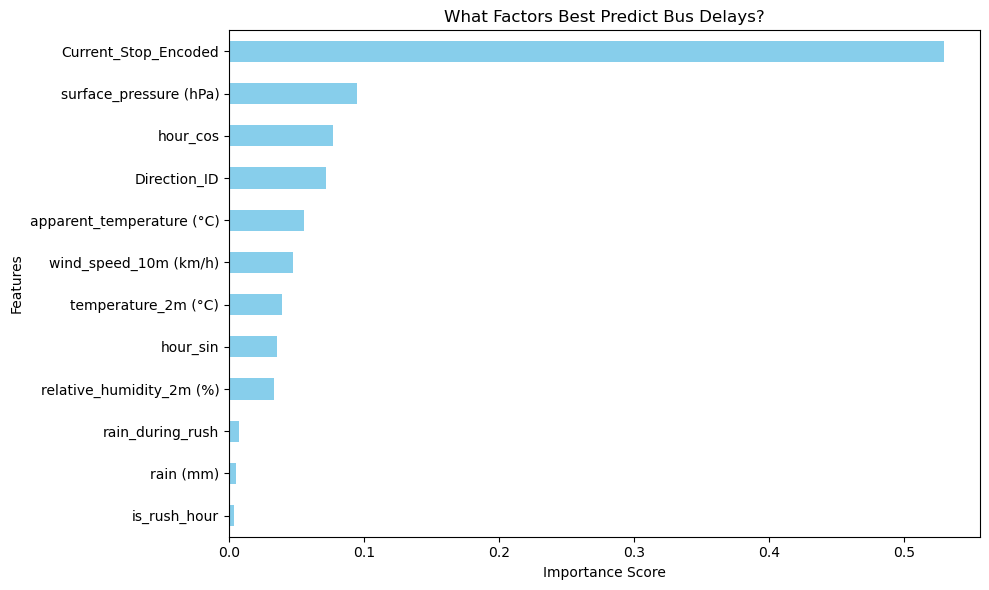

In [8]:
# Step 8
import matplotlib.pyplot as plt
import pandas as pd

# 1. Grab the column names of the numeric features we actually trained the model on
trained_features = Y_train.select_dtypes(include=["number"]).columns

# 2. Grab how much the model cared about each column using the correct feature index
importances = pd.Series(model.feature_importances_, index=trained_features)

# Sort them to find the top features
sorted_importances = importances.sort_values(ascending=False)

print("--- Top 10 Feature Importances ---")
print(sorted_importances.head(10))

# 3. Plot the top features for easy comparison
plt.figure(figsize=(10, 6))
sorted_importances.head(12).plot(kind="barh", color="skyblue")
plt.gca().invert_yaxis()  # Put the most important feature at the top
plt.title("What Factors Best Predict Bus Delays?")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [9]:
# Step 9
import joblib

# Save the trained Random Forest model
joblib.dump(model, "bus_delay_rf_model_039.pkl")

# Save your bus stop lookup averages (crucial for encoding new data!)
joblib.dump(stop_means, "stop_means_lookup_039.pkl")

print("Model and encoder successfully exported!")

Model and encoder successfully exported!
